In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import os
os.environ['R_HOME'] = 'D:/Program Files/R-4.5.0' #@TODO include in some setup file

from simulation_engine.scenarios.iv.binary_iv import BinaryIV
from simulation_engine.scenarios.conf.binary_conf import BinaryConf
from simulation_engine.scenarios.iv.continuous_iv import ContinuousIV
from simulation_engine.util.plotting_util import PlottingUtil

import pandas as pd
pd.set_option('display.max_columns', None)

#disable warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns
import math
# from linearmodels.iv import IV2SLS
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neural_network import MLPClassifier
# Train a decision tree classifier to predict 'tightest_bounds'
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from simulation_engine.util.plotting_util import PlottingUtil
pd.options.mode.chained_assignment = None  # default='warn'
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np




In [4]:
binConf = pd.read_pickle('../binConf/17_06/results.pkl')
binIV = pd.read_pickle('../binIV/17_06/results.pkl')
contConf = pd.read_pickle('../contConf/17_06/results.pkl')
contIV = pd.read_pickle('../contIV/17_06/results.pkl')

                    Algorithm Fail Rate (%) Invalid Rate (%) Net Bound Width Bound Width Invalid Δ (%)
                 ATE_OLS-0.95          0.00            13.40          0.1616      0.4080          1.20
                 ATE_OLS-0.98          0.00             7.70          0.1911      0.3304          1.12
                 ATE_OLS-0.99          0.00             5.05          0.2111      0.3014          1.13
       ATE_entropybounds-0.10          0.00            20.50          0.6464      0.9239          4.88
           ATE_zaffalonbounds          0.00             4.05          0.6609      0.7152          1.04
       ATE_entropybounds-0.20          0.00            10.00          0.8115      0.9304          4.27
                ATE_tianpearl          0.00             5.50          0.8651      0.9275          2.02
ATE_entropybounds-randomTheta          0.00            10.50          0.9049      1.0199          5.21
  ATE_entropybounds-trueTheta          0.00             7.75          0.9

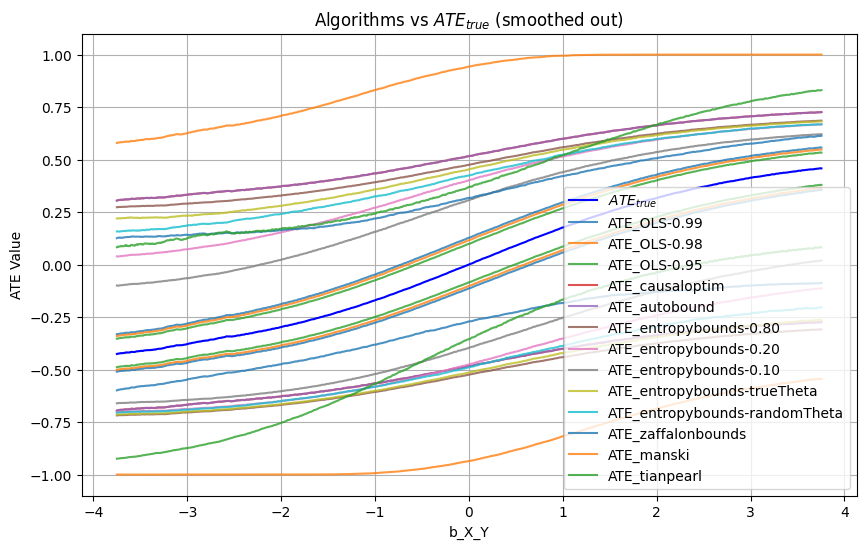

In [7]:
#ATE Evaluation
# Extract unique algorithm names from columns like 'ATE_{algorithm_name}_{...}'
df = binConf.copy()
algorithm_names = PlottingUtil.extract_algorithm_names(df, 'ATE')
PlottingUtil.print_bound_statistics_table(df, algorithm_names)
PlottingUtil.plot_smoothed_query_vs_bounds(df, 'ATE', algorithm_names, 500)

In [95]:
df = PlottingUtil.compute_bestAlg(contIV, 'ATE', 0.01)
algorithm_names = PlottingUtil.extract_algorithm_names(df, 'ATE')
PlottingUtil.print_bound_statistics_table(df, algorithm_names)
df['ATE_bestAlg'].value_counts()

                            Algorithm Fail Rate (%) Invalid Rate (%) Net Bound Width Bound Width Invalid Δ (%)
       ATE_entropybounds-0.10--binned          0.00            16.50          0.5795      0.8139          6.20
           ATE_zaffalonbounds--binned          0.00            23.35          0.6672      0.9784          7.44
                        ATE_2SLS-0.95          0.35            30.41          0.7181      1.1110          6.53
              ATE_causaloptim--binned          5.20            21.04          0.7281      1.0480          8.86
       ATE_entropybounds-0.20--binned          0.00             7.50          0.7501      0.8438          5.89
                        ATE_2SLS-0.98          0.35            26.19          0.7741      1.0984          6.69
                ATE_autobound--binned         11.40            11.17          0.7954      1.0520          7.27
                  ATE_zhangbareinboim          1.20             7.69          0.8022      0.9076          5.20
 

ATE_bestAlg
2SLS-0.95                            736
entropybounds-0.10--binned           585
zaffalonbounds--binned               294
causaloptim--binned                  107
tianpearl--binned                     80
entropybounds-randomTheta--binned     70
2SLS-0.98                             37
2SLS-0.99                             31
entropybounds-0.20--binned            26
zhangbareinboim                       22
autobound--binned                     12
Name: count, dtype: int64

In [15]:
bestAlg_ATE_binConf = PlottingUtil.compute_bestAlg(binConf, 'ATE', 0.01)    
bestAlg_ATE_binIV = PlottingUtil.compute_bestAlg(binIV, 'ATE', 0.01)
bestAlg_PNS_binConf = PlottingUtil.compute_bestAlg(binConf, 'PNS', 0.01)
bestAlg_PNS_binIV = PlottingUtil.compute_bestAlg(binIV, 'PNS', 0.01)
bestAlg_ATE_contConf = PlottingUtil.compute_bestAlg(contConf, 'ATE', 0.01)
bestAlg_ATE_contIV = PlottingUtil.compute_bestAlg(contIV, 'ATE', 0.01)

scenarios = {
    'BinaryConf': {'ATE': bestAlg_ATE_binConf['ATE_bestAlg'], 'PNS': bestAlg_PNS_binConf['PNS_bestAlg']},
    'BinaryIV': {'ATE': bestAlg_ATE_binIV['ATE_bestAlg'], 'PNS': bestAlg_PNS_binIV['PNS_bestAlg']},
    'ContConf': {'ATE': bestAlg_ATE_contConf['ATE_bestAlg']},
    'ContIV': {'ATE': bestAlg_ATE_contIV['ATE_bestAlg']}
}

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Flatten to dataframe
# data = []
# for scenario, results in scenarios.items():
#     for query_type, series in results.items():
#         counter = Counter(series)
#         total = len(series)
#         for alg, count in counter.items():
#             data.append({
#                 'Scenario': scenario,
#                 'Query': query_type,
#                 'Algorithm': alg,
#                 'Count': count,
#                 'Fraction': count / total
#             })

data = []
for scenario, results in scenarios.items():
    for query_type, series in results.items():
        counter = Counter(series)
        total = len(series)
        for alg, count in counter.items():
            # Make sure alg is a string before checking for suffix
            if isinstance(alg, str) and "--binned" in alg:
                base_name = alg.replace("--binned", "")
                alg_name  = f"{base_name} (binned)"
            else:
                # If alg is None or anything else, cast to string
                alg_name = str(alg)
            data.append({
                'Scenario': scenario,
                'Query':     query_type,
                'Algorithm': alg_name,
                'Count':     count,
                'Fraction':  count / total
            })

# Now build the DataFrame
df = pd.DataFrame(data)

# Group binned variants and recompute fractions
df = (
    df
    .groupby(['Scenario','Query','Algorithm'], as_index=False)['Count']
    .sum()
)
df['Fraction'] = df.groupby(['Scenario','Query'])['Count'].transform(lambda x: x / x.sum())

TypeError: argument of type 'NoneType' is not iterable

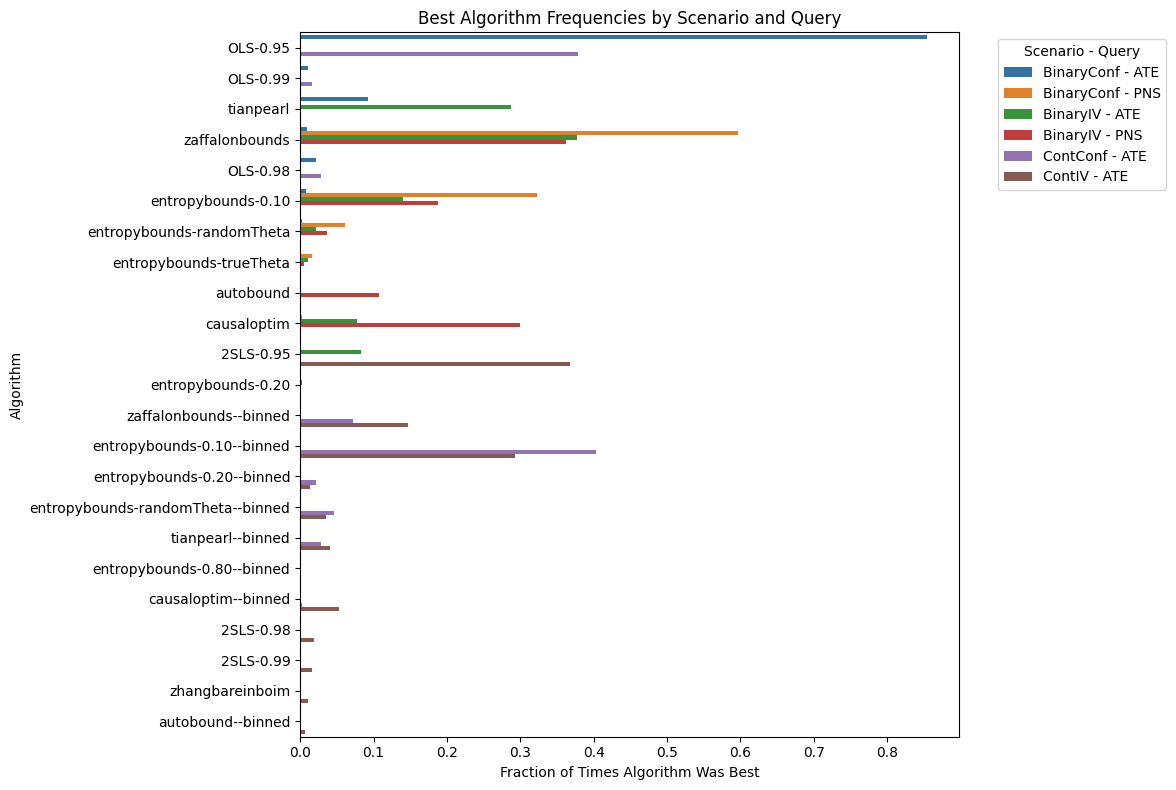

In [13]:
# Add combined identifier for hue
df['Scenario_Query'] = df['Scenario'] + ' - ' + df['Query']

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(
    data=df,
    y='Algorithm',
    x='Fraction',
    hue='Scenario_Query',
    orient='h'
)

# Styling
plt.title('Best Algorithm Frequencies by Scenario and Query')
plt.xlabel('Fraction of Times Algorithm Was Best')
plt.ylabel('Algorithm')
plt.legend(title='Scenario - Query', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\tmari\AppData\Local\Temp\ipykernel_16064\1836988827.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(algorithm_list))
C:\Users\tmari\AppData\Local\Temp\ipykernel_16064\1836988827.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


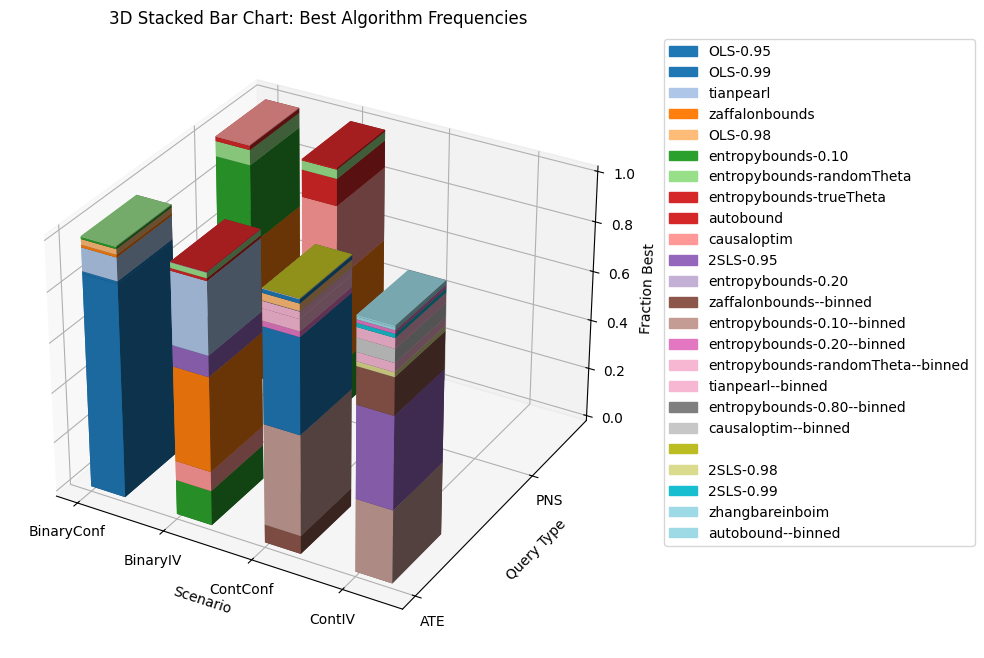

In [ ]:
### Useless 3D Plot
# Mappings
scenarios_list = df['Scenario'].unique()
scenario_map = {s: i for i, s in enumerate(scenarios_list)}
query_map = {'ATE': 0, 'PNS': 1}
algorithm_list = df['Algorithm'].unique()
algorithm_map = {alg: i for i, alg in enumerate(algorithm_list)}

# Colormap
colors = cm.get_cmap('tab20', len(algorithm_list))

# Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

dx = 0.4
dy = 0.4

# Group by scenario and query, then stack fractions
for (scenario, query), group in df.groupby(['Scenario', 'Query']):
    x = scenario_map[scenario]
    y = query_map[query]
    bottom = 0
    for _, row in group.iterrows():
        dz = row['Fraction']
        color = colors(algorithm_map[row['Algorithm']])
        ax.bar3d(x, y, bottom, dx, dy, dz, color=color, shade=True)
        bottom += dz

# Axis formatting
ax.set_xlabel('Scenario')
ax.set_ylabel('Query Type')
ax.set_zlabel('Fraction Best')
ax.set_xticks(list(scenario_map.values()))
ax.set_xticklabels(list(scenario_map.keys()))
ax.set_yticks(list(query_map.values()))
ax.set_yticklabels(list(query_map.keys()))
ax.set_title('3D Stacked Bar Chart: Best Algorithm Frequencies')

# Optional: Add color legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=colors(algorithm_map[alg]), label=alg) for alg in algorithm_list]
plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [80]:
#create new df that only contains best algorithms and scenario description
# Compute row-wise correlation between X and Y (which are lists/arrays per row)


bestAlg_ATE_binConf_simple = pd.DataFrame({
    'query': 'ATE',
    'ATE_bestAlg': bestAlg_ATE_binConf['ATE_bestAlg'],
    'Instrument': False,
    'Contiunous': False,
    # 'entropy_X': bestAlg_ATE_binConf['entropy_X'],
    # 'entropy_U': bestAlg_ATE_binConf['entropy_U'],
    # 'entropy_Y': bestAlg_ATE_binConf['entropy_Y'],
    # 'corr_XY': bestAlg_ATE_binConf.apply(lambda row: np.corrcoef(row['X'], row['Y'])[0, 1], axis=1)
})

bestAlg_ATE_binIV_simple = pd.DataFrame({
    'query': 'ATE',
    'ATE_bestAlg': bestAlg_ATE_binIV['ATE_bestAlg'],
    'Instrument': True,
    'Contiunous': False,
})

bestAlg_ATE_contConf_simple = pd.DataFrame({
    'query': 'ATE',
    'ATE_bestAlg': bestAlg_ATE_contConf['ATE_bestAlg'],
    'Instrument': False,
    'Contiunous': True,
})

bestAlg_ATE_contIV_simple = pd.DataFrame({
    'query': 'ATE',
    'ATE_bestAlg': bestAlg_ATE_contIV['ATE_bestAlg'],
    'Instrument': True,
    'Contiunous': True,
})

## Combine all the simple dataframes into one
bestAlg_ATE_simple = pd.concat([
    bestAlg_ATE_binConf_simple,
    bestAlg_ATE_binIV_simple,
    bestAlg_ATE_contConf_simple,
    bestAlg_ATE_contIV_simple
], ignore_index=True)

# Drop rows where ATE_bestAlg is None or NaN
filtered = bestAlg_ATE_simple.dropna(subset=['ATE_bestAlg'])

#train a decision tree classifier to predict bestAlg
X = filtered[['Instrument', 'Contiunous']]
y = filtered['ATE_bestAlg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


                                   precision    recall  f1-score   support

                        2SLS-0.95       0.38      0.82      0.52       180
                        2SLS-0.98       0.00      0.00      0.00         4
                        2SLS-0.99       0.00      0.00      0.00         5
                         OLS-0.95       0.87      0.69      0.77       528
                         OLS-0.98       0.00      0.00      0.00        22
                         OLS-0.99       0.00      0.00      0.00        10
                autobound--binned       0.00      0.00      0.00         2
                      causaloptim       0.00      0.00      0.00        34
              causaloptim--binned       0.00      0.00      0.00        21
               entropybounds-0.10       0.00      0.00      0.00        56
       entropybounds-0.10--binned       0.38      0.59      0.46       260
               entropybounds-0.20       0.00      0.00      0.00         1
       entropybounds-0.2

C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [84]:
bestAlg_ATE_binConf_simple['ATE_bestAlg'].value_counts()

ATE_bestAlg
OLS-0.95                     1709
tianpearl                     184
OLS-0.98                       44
OLS-0.99                       21
zaffalonbounds                 20
entropybounds-0.10             16
entropybounds-randomTheta       6
Name: count, dtype: int64